# DreamBooth: Full-Model Identity Personalization

This notebook is the third experiment in the Stable Diffusion personalization study.

DreamBooth is the heaviest adaptation method in this comparison. The provided configuration fine-tunes the diffusion model for a unique instance token and also trains the text encoder, while prior-preservation images are used to reduce class drift.

I evaluate the personalized checkpoint first with direct text-to-image generation and then with OpenPose ControlNet.


## 1. DreamBooth Training


In [1]:
!curl -O https://raw.githubusercontent.com/huggingface/diffusers/v0.29.2/examples/dreambooth/train_dreambooth.py


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 58461  100 58461    0     0   156k      0 --:--:-- --:--:-- --:--:--  156k


I train the token `sks person` from the same identity dataset used in the other experiments. Unlike Textual Inversion, this changes model parameters rather than learning only a new embedding.


In [2]:
%%bash
python3 ./train_dreambooth.py \
--pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
--instance_data_dir=./jortega \
--instance_prompt="a photo of a sks person" \
--class_prompt="a photo of a person" \
--class_data_dir=./class_person \
--with_prior_preservation \
--output_dir=./sd15_runway_dreambooth_jortega \
--seed=42 \
--train_text_encoder \
--resolution=512 \
--train_batch_size=1 \
--dataloader_num_workers=1 \
--max_train_steps=2000 \
--gradient_accumulation_steps=1 \
--gradient_checkpointing \
--learning_rate=1e-6 \
--lr_scheduler=constant \
--mixed_precision=fp16 \
--checkpointing_steps=1000 \
--max_grad_norm=1.0


/home/jovyan/.local/lib/python3.12/site-packages/accelerate/accelerator.py:529: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
09/05/2026 15:30:54 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
{'rescale_betas_zero_snr', 'thresholding', 'sample_max_value', 'prediction_type', 'variance_type', 'clip_sample_range', 'timestep_spacing', 'dynamic_thresholding_ratio'} was not found in config. Values will be initialized to default values.
{'shift_factor', 'use_quant_conv', 'latents_std', 'mid_block_add_attention', 'force_upcast', 'scaling_factor', 'latents_mean', 'u

## 2. Identity Generation

I load the personalized DreamBooth checkpoint and generate a portrait using the learned instance token.


In [3]:
import torch
import requests
from io import BytesIO

import cv2
import numpy as np
from PIL import Image
from IPython.display import display

from diffusers import AutoencoderKL, ControlNetModel, EulerAncestralDiscreteScheduler
from diffusers import StableDiffusionPipeline, StableDiffusionControlNetPipeline, UNet2DConditionModel

from controlnet_aux import OpenposeDetector
from transformers import CLIPTextModel

/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_11m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_11m_224. This is because the name being registered conflicts with an existing name. Please che

In [4]:
device = torch.device("cuda")
dtype = torch.bfloat16

pipe = StableDiffusionPipeline.from_pretrained(
    "./sd15_runway_dreambooth_jortega",
    vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=dtype, use_safetensors=True),
    torch_dtype=dtype,
    safety_checker=None,
    use_safetensors=True
).to(device, dtype)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [5]:
pipe_scheduler_config = pipe.scheduler.config
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe_scheduler_config)

  0%|          | 0/50 [00:00<?, ?it/s]

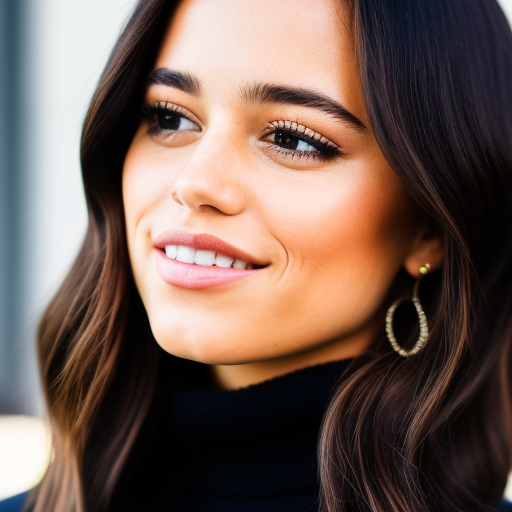

In [6]:
img = pipe(
    prompt="instagram photo, closeup face photo of sks person in black sweater, pale skin, smile, hard shadows",
    negative_prompt="nsfw, naked, nude, deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime, mutated hands and fingers, deformed, distorted, disfigured, poorly drawn, bad anatomy, wrong anatomy, extra limb, missing limb, floating limbs, disconnected limbs, mutation, mutated, ugly, disgusting, amputation",
    height=512, width=512,
    num_inference_steps=50,
    guidance_scale=7.0,
    generator=torch.Generator(device=device).manual_seed(42),
).images[0]

img

### Observation

The personalized checkpoint captures the overall appearance of the target identity, but exact facial similarity is still imperfect. This provides a useful contrast with the training-free FaceID conditioning and the lighter embedding/adaptor approaches.


## 3. Pose-Controlled Generation

I reuse the personalized DreamBooth components inside a Stable Diffusion ControlNet pipeline and apply the same type of OpenPose constraint used in the other notebooks.


In [7]:
pose_detector = OpenposeDetector.from_pretrained("lllyasviel/ControlNet")

/home/jovyan/.local/lib/python3.12/site-packages/controlnet_aux/open_pose/body.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = util.transfer(self.model, to

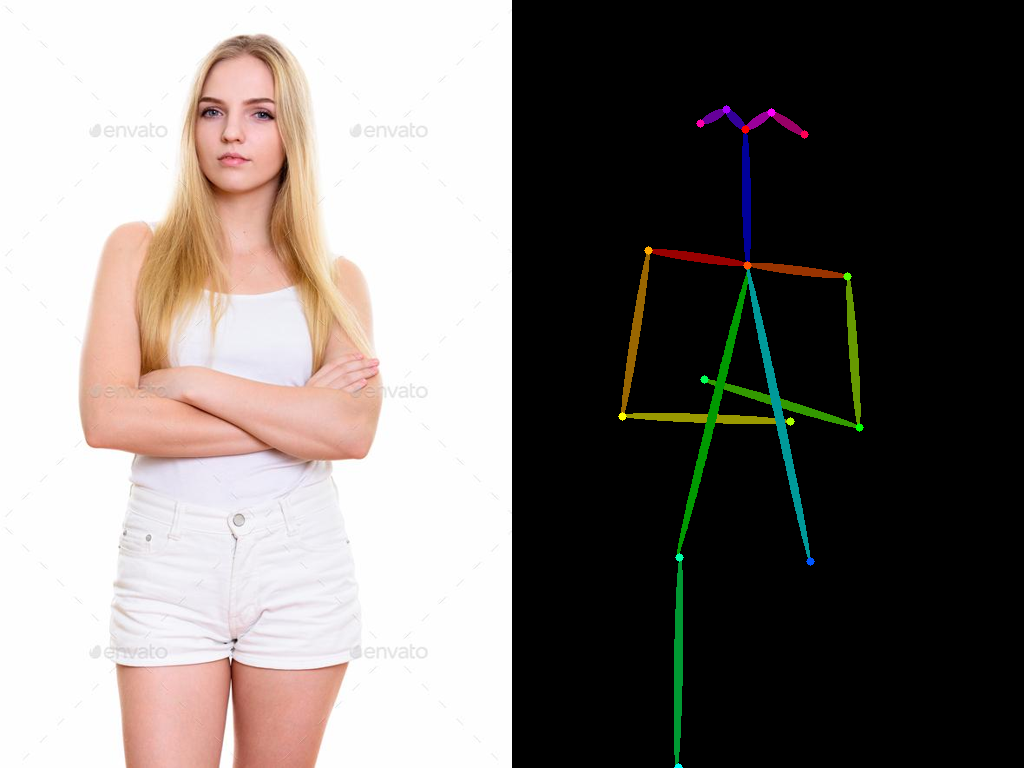

In [8]:
url = "https://s3.envato.com/files/287416893/23rdJanuary2017-4.jpg"
response = requests.get(url)
Image.open(BytesIO(response.content)).save("photo.jpg")

pose = pose_detector(Image.open("photo.jpg"))

Image.fromarray(np.hstack((
    np.asarray(Image.open("photo.jpg").resize((pose.width, pose.height))),
    np.asarray(pose),
)))


In [9]:
controlnet_pose = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-openpose", torch_dtype=torch.float16
).to(device)

In [10]:
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "./sd15_runway_dreambooth_jortega",
    controlnet=controlnet_pose,
    vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=dtype, use_safetensors=True),
    torch_dtype=dtype,
    safety_checker=None,
    use_safetensors=True
).to(device, dtype)

pipe_scheduler_config = pipe.scheduler.config
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe_scheduler_config)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

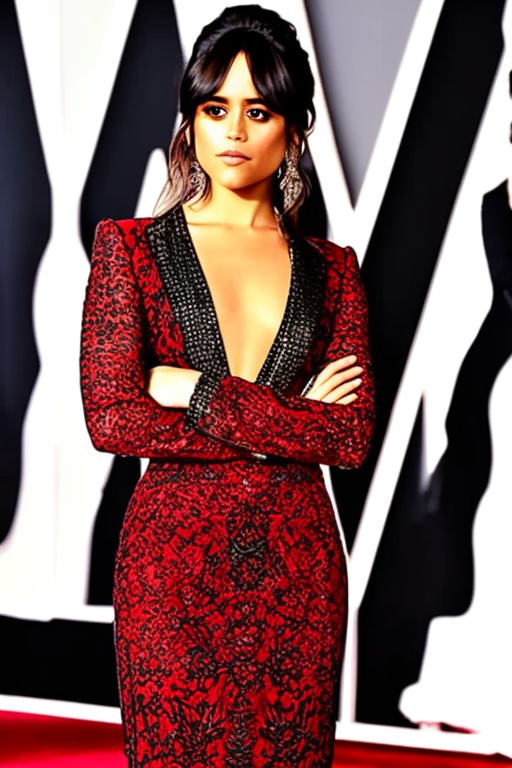

In [11]:
img = pipe(
    prompt="instagram photo, photo of sks person in a beautiful dress on a red carpet",
    negative_prompt="nsfw, naked, nude, deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime, mutated hands and fingers, deformed, distorted, disfigured, poorly drawn, bad anatomy, wrong anatomy, extra limb, missing limb, floating limbs, disconnected limbs, mutation, mutated, ugly, disgusting, amputation",
    guidance_scale=7,
    height=pose.height, width=pose.width,
    num_inference_steps=50,
    generator=torch.Generator(device=device).manual_seed(123),
    image=pose,
    controlnet_conditioning_scale=1.0,
).images[0]

img


### Observation

The model follows the pose and keeps broad identity characteristics, although facial similarity degrades under the additional spatial constraint. DreamBooth gives the model the largest adaptation capacity in this series, but that does not automatically guarantee perfect identity preservation.
